In [1]:
#п.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [4]:
print(df.head())
print(f"\nРазмер данных: {df.shape}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Размер данных: (20640, 9)


In [5]:
#п.2
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [16]:
#п.3
target = 'MedHouseVal'
y = df[target]
X = df.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


In [18]:
#п.4
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)

y_train_pred_1 = model_1.predict(X_train_scaled)
y_test_pred_1 = model_1.predict(X_test_scaled)

rmse_train_1 = np.sqrt(mean_squared_error(y_train, y_train_pred_1))
r2_train_1 = r2_score(y_train, y_train_pred_1)
rmse_test_1 = np.sqrt(mean_squared_error(y_test, y_test_pred_1))
r2_test_1 = r2_score(y_test, y_test_pred_1)

print(f'Train: RMSE = {rmse_train_1:.4f}, R2 = {r2_train_1:.4f}')
print(f'Test:  RMSE = {rmse_test_1:.4f}, R2 = {r2_test_1:.4f}')

Train: RMSE = 0.7197, R2 = 0.6126
Test:  RMSE = 0.7456, R2 = 0.5758


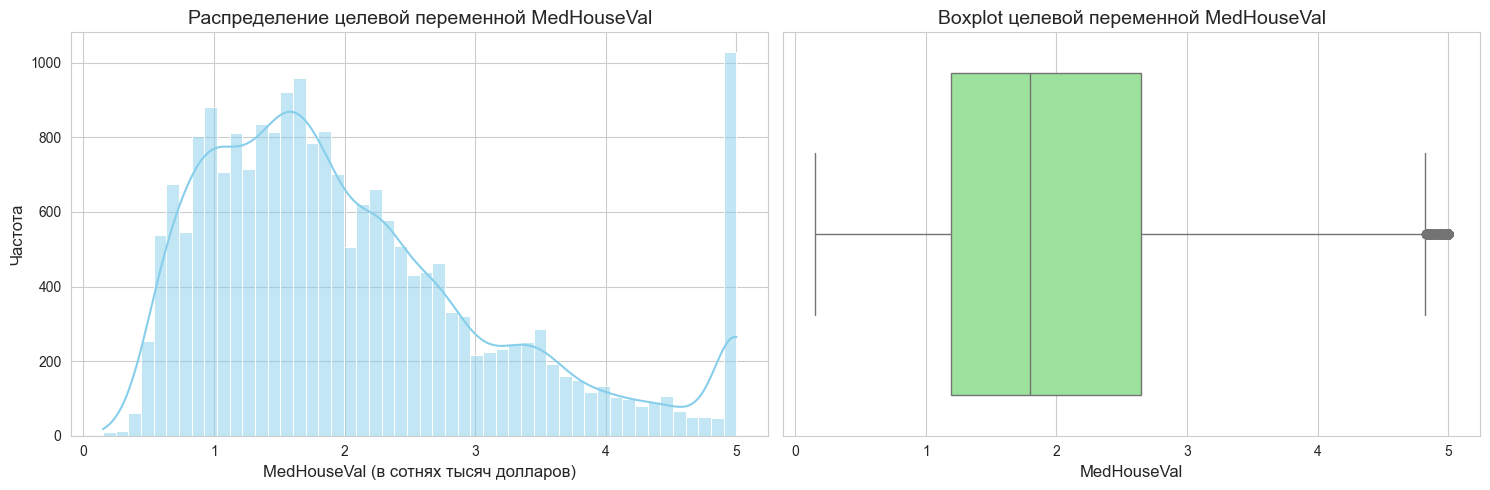


ВЫВОДЫ по распределению целевой переменной:
- Распределение имеет правую асимметрию
- Значения > 5 были заменены на 5 (искусственное ограничение)
- Основная масса домов имеет стоимость от 1 до 3 (в сотнях тысяч $)
- Явных выбросов не наблюдается, так как данные уже обработаны


In [40]:
#п.5
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, bins=50, color='skyblue')
plt.title('Распределение целевой переменной MedHouseVal', fontsize=14)
plt.xlabel('MedHouseVal (в сотнях тысяч долларов)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x=y, color='lightgreen')
plt.title('Boxplot целевой переменной MedHouseVal', fontsize=14)
plt.xlabel('MedHouseVal', fontsize=12)

plt.tight_layout()
plt.show()

print("""
ВЫВОДЫ по распределению целевой переменной:
- Распределение имеет правую асимметрию
- Значения > 5 были заменены на 5 (искусственное ограничение)
- Основная масса домов имеет стоимость от 1 до 3 (в сотнях тысяч $)
- Явных выбросов не наблюдается, так как данные уже обработаны""")

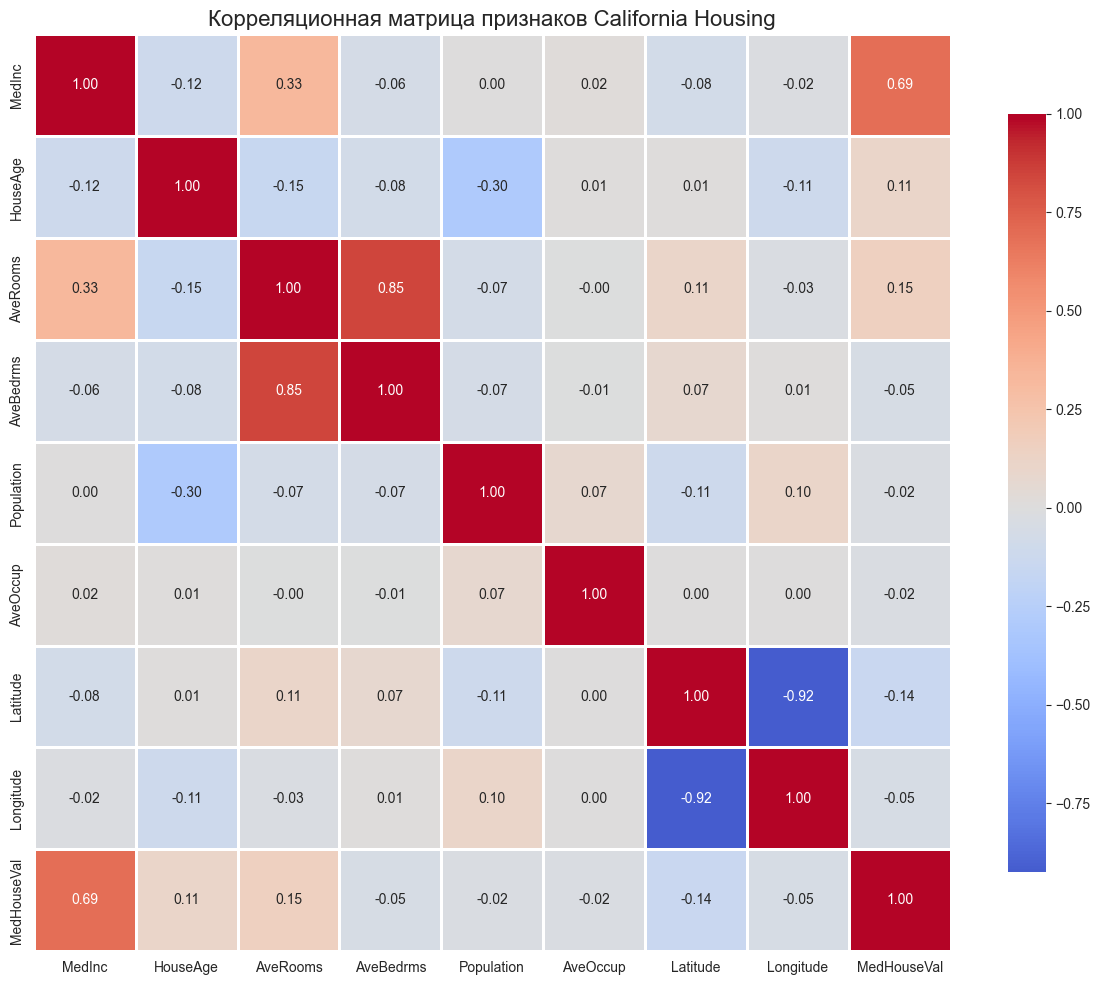

Корреляция признаков с целевой переменной MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

ВЫВОДЫ по корреляционному анализу:
- MedInc (медианный доход) имеет самую сильную корреляцию (0.69)
- Latitude и Longitude имеют отрицательную корреляцию (важность географии)
- AveRooms и AveBedrms имеют слабую положительную корреляцию
- Population и HouseAge имеют очень слабую связь с ценой


In [42]:
#п.6
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков California Housing', fontsize=16)
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix[target].sort_values(ascending=False)
print("Корреляция признаков с целевой переменной MedHouseVal:")
print(corr_with_target)

print("""
ВЫВОДЫ по корреляционному анализу:
- MedInc (медианный доход) имеет самую сильную корреляцию (0.69)
- Latitude и Longitude имеют отрицательную корреляцию (важность географии)
- AveRooms и AveBedrms имеют слабую положительную корреляцию
- Population и HouseAge имеют очень слабую связь с ценой""")

In [23]:
selected_features = ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
print(f"Отобранные признаки (с корреляцией > 0.1 по модулю): {selected_features}")

X_selected = df[selected_features]

Отобранные признаки (с корреляцией > 0.1 по модулю): ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']


In [25]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

model_2 = LinearRegression()
model_2.fit(X_train_sel_scaled, y_train_sel)

y_train_pred_2 = model_2.predict(X_train_sel_scaled)
y_test_pred_2 = model_2.predict(X_test_sel_scaled)

rmse_train_2 = np.sqrt(mean_squared_error(y_train_sel, y_train_pred_2))
r2_train_2 = r2_score(y_train_sel, y_train_pred_2)
rmse_test_2 = np.sqrt(mean_squared_error(y_test_sel, y_test_pred_2))
r2_test_2 = r2_score(y_test_sel, y_test_pred_2)

print(f'Train: RMSE = {rmse_train_2:.4f}, R2 = {r2_train_2:.4f}')
print(f'Test:  RMSE = {rmse_test_2:.4f}, R2 = {r2_test_2:.4f}')

Train: RMSE = 0.7301, R2 = 0.6012
Test:  RMSE = 0.7528, R2 = 0.5675


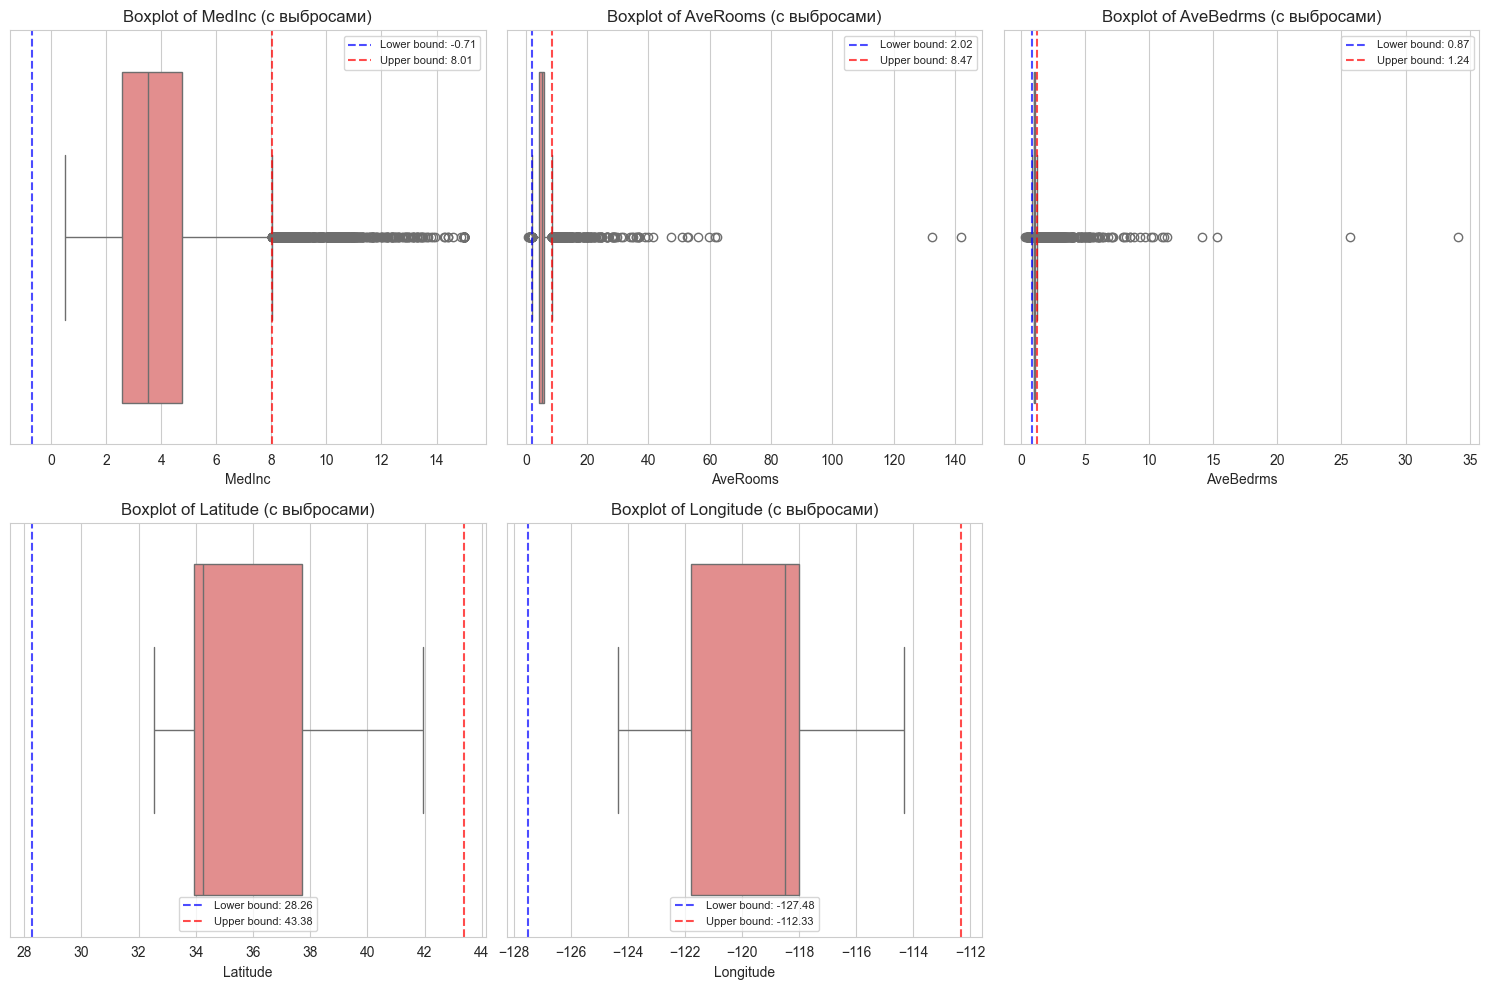

Количество выбросов по каждому признаку:
MedInc: 681 выбросов
AveRooms: 511 выбросов
AveBedrms: 1424 выбросов
Latitude: 0 выбросов
Longitude: 0 выбросов


In [26]:
#п.7
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col} (с выбросами)', fontsize=12)
    outliers, lb, ub = detect_outliers_iqr(df, col)
    plt.axvline(x=lb, color='blue', linestyle='--', alpha=0.7, label=f'Lower bound: {lb:.2f}')
    plt.axvline(x=ub, color='red', linestyle='--', alpha=0.7, label=f'Upper bound: {ub:.2f}')
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Количество выбросов по каждому признаку:")
for col in selected_features:
    outliers, _, _ = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} выбросов")

In [27]:
df_no_outliers = df.copy()
outlier_indices = set()

for col in selected_features:
    outliers, _, _ = detect_outliers_iqr(df_no_outliers, col)
    outlier_indices = outlier_indices.union(set(outliers.index))
    print(f"{col}: удалено {len(outliers)} выбросов")

df_no_outliers = df_no_outliers.drop(index=outlier_indices)
print(f"\nРазмер данных до удаления выбросов: {df.shape}")
print(f"Размер данных после удаления выбросов: {df_no_outliers.shape}")
print(f"Всего удалено строк: {df.shape[0] - df_no_outliers.shape[0]}")

MedInc: удалено 681 выбросов
AveRooms: удалено 511 выбросов
AveBedrms: удалено 1424 выбросов
Latitude: удалено 0 выбросов
Longitude: удалено 0 выбросов

Размер данных до удаления выбросов: (20640, 9)
Размер данных после удаления выбросов: (18501, 9)
Всего удалено строк: 2139


In [28]:
y_no_out = df_no_outliers[target]
X_no_out = df_no_outliers[selected_features]

X_train_no_out, X_test_no_out, y_train_no_out, y_test_no_out = train_test_split(
    X_no_out, y_no_out, test_size=0.2, random_state=42
)

scaler_no_out = StandardScaler()
X_train_no_out_scaled = scaler_no_out.fit_transform(X_train_no_out)
X_test_no_out_scaled = scaler_no_out.transform(X_test_no_out)

model_3 = LinearRegression()
model_3.fit(X_train_no_out_scaled, y_train_no_out)

y_train_pred_3 = model_3.predict(X_train_no_out_scaled)
y_test_pred_3 = model_3.predict(X_test_no_out_scaled)

rmse_train_3 = np.sqrt(mean_squared_error(y_train_no_out, y_train_pred_3))
r2_train_3 = r2_score(y_train_no_out, y_train_pred_3)
rmse_test_3 = np.sqrt(mean_squared_error(y_test_no_out, y_test_pred_3))
r2_test_3 = r2_score(y_test_no_out, y_test_pred_3)

print(f'Train: RMSE = {rmse_train_3:.4f}, R2 = {r2_train_3:.4f}')
print(f'Test:  RMSE = {rmse_test_3:.4f}, R2 = {r2_test_3:.4f}')

Train: RMSE = 0.6954, R2 = 0.5597
Test:  RMSE = 0.7202, R2 = 0.5529


Создание новых математических преобразований:
- Log_MedInc: логарифм медианного дохода
- Log_AveRooms: логарифм среднего количества комнат
- MedInc_squared: квадрат медианного дохода
- Sqrt_AveRooms: квадратный корень из среднего количества комнат
- Rooms_per_Bedroom: отношение комнат к спальням


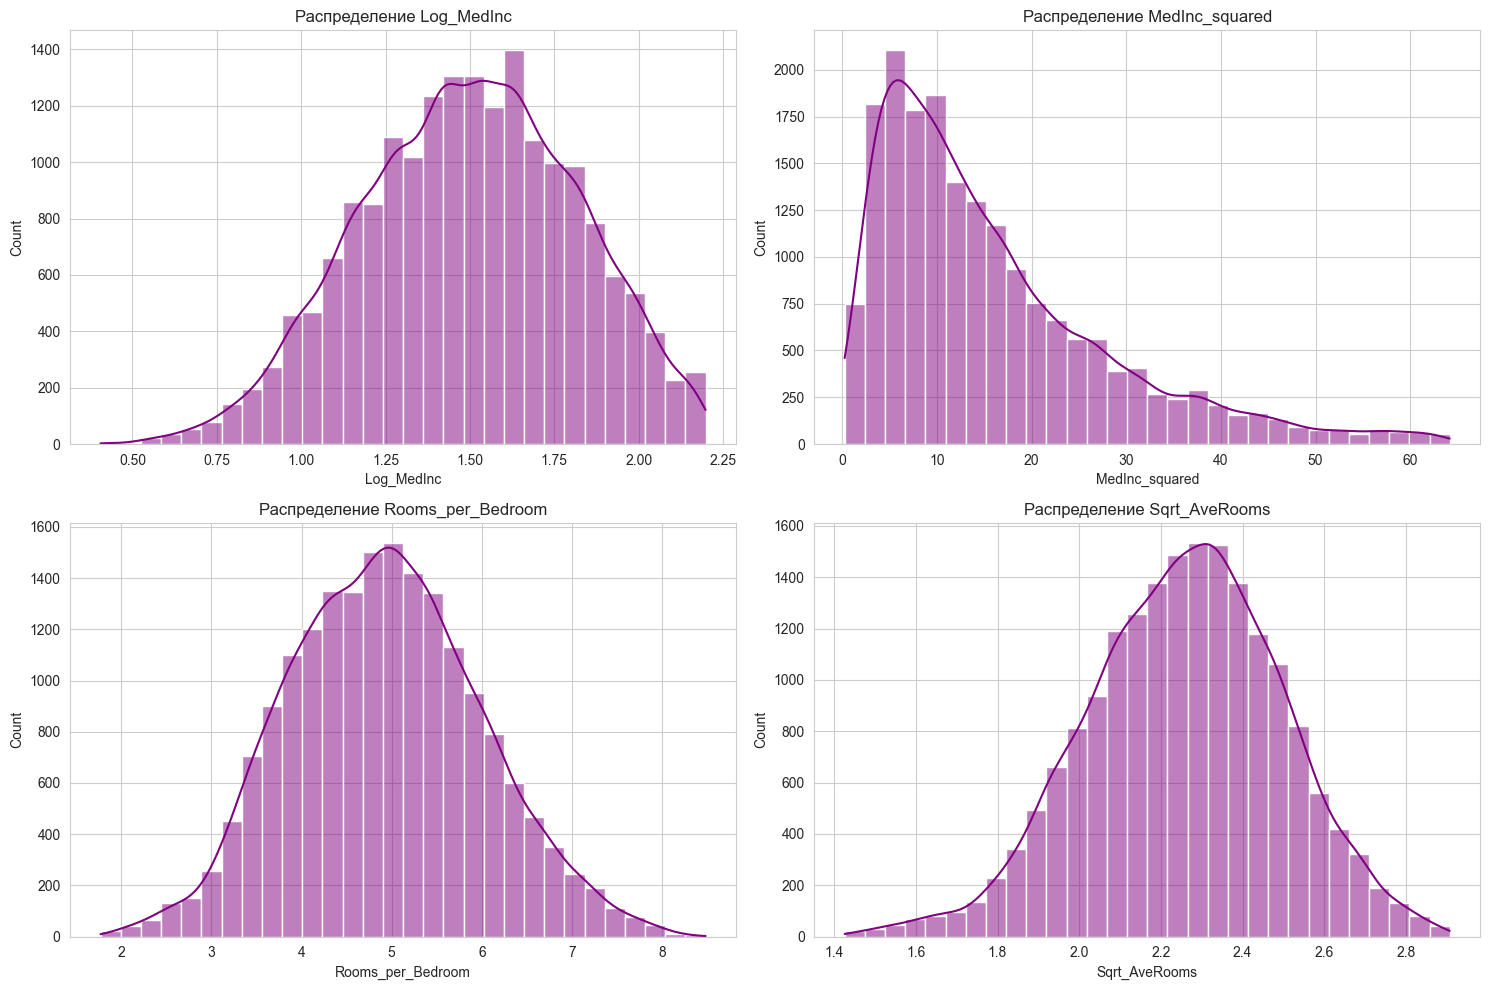

In [36]:
df_transformed = df_no_outliers.copy()

print("Создание новых математических преобразований:")

df_transformed['Log_MedInc'] = np.log1p(df_transformed['MedInc'])
print("- Log_MedInc: логарифм медианного дохода")

df_transformed['Log_AveRooms'] = np.log1p(df_transformed['AveRooms'])
print("- Log_AveRooms: логарифм среднего количества комнат")

df_transformed['MedInc_squared'] = df_transformed['MedInc'] ** 2
print("- MedInc_squared: квадрат медианного дохода")

df_transformed['Sqrt_AveRooms'] = np.sqrt(df_transformed['AveRooms'])
print("- Sqrt_AveRooms: квадратный корень из среднего количества комнат")

df_transformed['Rooms_per_Bedroom'] = df_transformed['AveRooms'] / df_transformed['AveBedrms']
print("- Rooms_per_Bedroom: отношение комнат к спальням")

plt.figure(figsize=(15, 10))
new_features = ['Log_MedInc', 'MedInc_squared', 'Rooms_per_Bedroom', 'Sqrt_AveRooms']
for i, col in enumerate(new_features):
    plt.subplot(2, 2, i+1)
    sns.histplot(df_transformed[col], kde=True, bins=30, color='purple')
    plt.title(f'Распределение {col}', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
final_features = ['MedInc', 'Latitude', 'Longitude', 'Log_MedInc', 'Rooms_per_Bedroom']
print(f"\nФинальные признаки для модели 4: {final_features}")

X_final = df_transformed[final_features]

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_no_out, test_size=0.2, random_state=42
)

scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

model_4 = LinearRegression()
model_4.fit(X_train_final_scaled, y_train_final)

y_train_pred_4 = model_4.predict(X_train_final_scaled)
y_test_pred_4 = model_4.predict(X_test_final_scaled)

rmse_train_4 = np.sqrt(mean_squared_error(y_train_final, y_train_pred_4))
r2_train_4 = r2_score(y_train_final, y_train_pred_4)
rmse_test_4 = np.sqrt(mean_squared_error(y_test_final, y_test_pred_4))
r2_test_4 = r2_score(y_test_final, y_test_pred_4)

print(f'Train: RMSE = {rmse_train_4:.4f}, R2 = {r2_train_4:.4f}')
print(f'Test:  RMSE = {rmse_test_4:.4f}, R2 = {r2_test_4:.4f}')


Финальные признаки для модели 4: ['MedInc', 'Latitude', 'Longitude', 'Log_MedInc', 'Rooms_per_Bedroom']
Train: RMSE = 0.6956, R2 = 0.5595
Test:  RMSE = 0.7214, R2 = 0.5514


In [44]:
print(""" Вывод
9a. Преобразования с данными:
    - Отобраны признаки по корреляции (MedInc, AveRooms, AveBedrms, Latitude, Longitude)
    - Удалены выбросы (2139 строк) по методу IQR
    - Созданы новые признаки: Log_MedInc, Rooms_per_Bedroom

9b. Сравнение метрик:
    --------------------------------------------------
    Модель                    | RMSE  | R2   
    --------------------------------------------------
    1. Все исходные признаки   | 0.7456 | 0.5758
    2. Отбор по корреляции     | 0.7528 | 0.5675
    3. Отбор + удаление выбросов| 0.7202 | 0.5529
    4. Feature Engineering     | 0.7214 | 0.5514
    --------------------------------------------------
    
    Лучший RMSE: Модель 3 (0.7202)
    Лучший R2:   Модель 1 (0.5758)

9c. Мнение о качестве моделей:
    - Модели объясняют 55-57% дисперсии цен
    - Удаление выбросов улучшило RMSE на 3.4%
    - Feature Engineering не дал улучшения
    - Для реального применения нужны более сложные модели
""")

 Вывод
9a. Преобразования с данными:
    - Отобраны признаки по корреляции (MedInc, AveRooms, AveBedrms, Latitude, Longitude)
    - Удалены выбросы (2139 строк) по методу IQR
    - Созданы новые признаки: Log_MedInc, Rooms_per_Bedroom

9b. Сравнение метрик:
    --------------------------------------------------
    Модель                    | RMSE  | R2   
    --------------------------------------------------
    1. Все исходные признаки   | 0.7456 | 0.5758
    2. Отбор по корреляции     | 0.7528 | 0.5675
    3. Отбор + удаление выбросов| 0.7202 | 0.5529
    4. Feature Engineering     | 0.7214 | 0.5514
    --------------------------------------------------
    
    Лучший RMSE: Модель 3 (0.7202)
    Лучший R2:   Модель 1 (0.5758)

9c. Мнение о качестве моделей:
    - Модели объясняют 55-57% дисперсии цен
    - Удаление выбросов улучшило RMSE на 3.4%
    - Feature Engineering не дал улучшения
    - Для реального применения нужны более сложные модели

